# Cross-patient Leading-edge Spot-size Benchmark

This notebook compares P2CRC, P1CRC, and P5CRC on their `part1` leading-edge regions for HVG50 and all evaluated genes. It writes two PDF figures to `output/spot_benchmark/`.

In [2]:
# [CONFIG] Imports, repository paths, and plot settings

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch


def find_repo_root():
    """Locate the REVISE_0812 repository root from the current directory."""
    current_dir = os.path.abspath(os.getcwd())

    while True:
        spot_notebook = os.path.join(
            current_dir,
            "reproduce",
            "benchmark",
            "spot.ipynb",
        )
        if os.path.exists(spot_notebook):
            return current_dir

        parent_dir = os.path.dirname(current_dir)
        if parent_dir == current_dir:
            break
        current_dir = parent_dir

    raise FileNotFoundError(
        "Cannot locate the REVISE_0812 repository root"
    )


ROOT = find_repo_root()
P2_RESULT_ROOT = os.path.join(ROOT, "results", "spot_sr_baseline")
P1_P5_METRICS = os.path.join(
    ROOT,
    "output",
    "spot_size_p1_p5_three_method_20260824T123453Z",
    "p1_p5_metrics_by_gene.csv",
)
SAVE_DIR = os.path.join(ROOT, "output", "spot_benchmark")
os.makedirs(SAVE_DIR, exist_ok=True)

PATIENTS = ["P2CRC", "P1CRC", "P5CRC"]
LEADING_EDGE_PART = {patient: "part1" for patient in PATIENTS}
SPOT_SIZES = [50, 100, 150, 200]
METRICS = ["PCC", "SSIM", "MSE"]
METHODS = ["REVISE", "Spotify/Spotiphy", "TESLA"]

P2_METHOD_IDS = {
    "REVISE": 4,
    "Spotify/Spotiphy": 2,
    "TESLA": 1,
}
P1_P5_METHOD_MAP = {
    "REVISE": "REVISE",
    "Spotiphy": "Spotify/Spotiphy",
    "TESLA": "TESLA",
}
COLORS = {
    "REVISE": "#b39a94",
    "Spotify/Spotiphy": "#8ccfd9",
    "TESLA": "#80a9c8",
}

In [3]:
# [DEFINE] Load P2CRC historical metrics

def load_p2_metrics(gene_set):
    """Load P2CRC part1 metrics from the historical benchmark."""
    frames = []
    part = LEADING_EDGE_PART["P2CRC"]

    for spot_size in SPOT_SIZES:
        for method in METHODS:
            method_id = P2_METHOD_IDS[method]
            case_dir = os.path.join(
                P2_RESULT_ROOT,
                part,
                f"{spot_size}_{method_id}",
            )
            metric_file = os.path.join(case_dir, "metrics_normalized.csv")

            if not os.path.exists(metric_file):
                raise FileNotFoundError(metric_file)

            df = pd.read_csv(metric_file)
            required_columns = {"Gene", *METRICS}
            missing_columns = required_columns.difference(df.columns)
            if missing_columns:
                raise ValueError(
                    f"{metric_file}: missing columns {sorted(missing_columns)}"
                )
            if df["Gene"].duplicated().any():
                raise ValueError(f"{metric_file}: duplicated genes")

            df = (
                df[["Gene", *METRICS]]
                .copy()
                .set_index("Gene", drop=False)
            )

            if gene_set == "HVG50":
                gene_file = os.path.join(
                    case_dir,
                    "select_gene",
                    "HVG_genes_50.txt",
                )
                if not os.path.exists(gene_file):
                    raise FileNotFoundError(gene_file)

                with open(gene_file, encoding="utf-8") as handle:
                    genes = handle.read().splitlines()

                if len(genes) != 50 or len(set(genes)) != 50:
                    raise ValueError(f"{gene_file}: expected 50 unique genes")

                missing_genes = sorted(set(genes).difference(df.index))
                if missing_genes:
                    raise ValueError(
                        f"{gene_file}: genes absent from metrics: {missing_genes}"
                    )
                df = df.loc[genes].copy()

            df["Patient"] = "P2CRC"
            df["Part"] = part
            df["Spot_size"] = spot_size
            df["Method"] = method
            frames.append(df.reset_index(drop=True))

    return pd.concat(frames, ignore_index=True)

In [4]:
# [DEFINE] Load P1CRC and P5CRC metrics

def load_p1_p5_metrics(gene_set):
    """Load P1CRC/P5CRC part1 metrics from the latest summary."""
    if not os.path.exists(P1_P5_METRICS):
        raise FileNotFoundError(P1_P5_METRICS)

    df = pd.read_csv(P1_P5_METRICS)
    required_columns = {
        "patient",
        "part",
        "spot_size",
        "method",
        "gene",
        "is_hvg50",
        *METRICS,
    }
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(
            f"{P1_P5_METRICS}: missing columns {sorted(missing_columns)}"
        )

    df["spot_size"] = pd.to_numeric(
        df["spot_size"],
        errors="raise",
    ).astype(int)
    df = df.loc[
        df["patient"].isin(["P1CRC", "P5CRC"])
        & (df["part"] == "part1")
        & df["spot_size"].isin(SPOT_SIZES)
        & df["method"].isin(P1_P5_METHOD_MAP)
    ].copy()

    unique_key = ["patient", "part", "spot_size", "method", "gene"]
    if df.duplicated(unique_key).any():
        raise ValueError(f"{P1_P5_METRICS}: duplicated case/gene rows")

    if gene_set == "HVG50":
        is_hvg50 = (
            df["is_hvg50"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("true")
        )
        df = df.loc[is_hvg50].copy()
        counts = df.groupby(["patient", "spot_size", "method"]).size()

        if len(counts) != 24 or not counts.eq(50).all():
            raise ValueError(f"Unexpected P1/P5 HVG50 counts:\n{counts}")

    df["method"] = df["method"].map(P1_P5_METHOD_MAP)
    df = df.rename(
        columns={
            "patient": "Patient",
            "part": "Part",
            "spot_size": "Spot_size",
            "method": "Method",
            "gene": "Gene",
        }
    )
    return df[["Patient", "Part", "Spot_size", "Method", "Gene", *METRICS]]

In [5]:
# [DEFINE] Merge and validate the cross-patient plot data

def build_plot_data(gene_set):
    """Combine P2/P1/P5 metrics into long-form plot data."""
    gene_set = gene_set.upper()
    if gene_set not in {"HVG50", "ALL"}:
        raise ValueError("gene_set must be 'HVG50' or 'ALL'")

    wide_df = pd.concat(
        [load_p2_metrics(gene_set), load_p1_p5_metrics(gene_set)],
        ignore_index=True,
    )

    expected_cases = pd.MultiIndex.from_product(
        [PATIENTS, SPOT_SIZES, METHODS],
        names=["Patient", "Spot_size", "Method"],
    )
    observed_cases = pd.MultiIndex.from_frame(
        wide_df[["Patient", "Spot_size", "Method"]].drop_duplicates()
    )
    missing_cases = expected_cases.difference(observed_cases)
    if len(missing_cases):
        raise ValueError(f"Missing cases: {list(missing_cases)}")

    for metric in METRICS:
        wide_df[metric] = pd.to_numeric(wide_df[metric], errors="raise")
        values = wide_df[metric].to_numpy(dtype=float)
        if np.isinf(values).any():
            raise ValueError(f"{metric} contains Inf")
        if metric != "PCC" and np.isnan(values).any():
            raise ValueError(f"{metric} contains unexpected NaN")

    long_df = wide_df.melt(
        id_vars=["Patient", "Part", "Spot_size", "Method", "Gene"],
        value_vars=METRICS,
        var_name="Metric",
        value_name="Value",
    )
    long_df["Patient"] = pd.Categorical(
        long_df["Patient"],
        categories=PATIENTS,
        ordered=True,
    )
    long_df["Method"] = pd.Categorical(
        long_df["Method"],
        categories=METHODS,
        ordered=True,
    )

    finite_mask = np.isfinite(long_df["Value"].to_numpy(dtype=float))
    return long_df.loc[finite_mask].copy()

In [6]:
# [DEFINE] Draw the 3 metrics × 3 patients comparison

def plot_leading_edge(gene_set):
    gene_set = gene_set.upper()
    plot_df = build_plot_data(gene_set)

    sns.set_theme(style="ticks", context="paper")
    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(12, 9),
        sharey="row",
    )

    for col, patient in enumerate(PATIENTS):
        for row, metric in enumerate(METRICS):
            ax = axes[row, col]
            panel_df = plot_df.loc[
                (plot_df["Patient"] == patient)
                & (plot_df["Metric"] == metric)
            ]

            sns.boxplot(
                data=panel_df,
                x="Spot_size",
                y="Value",
                hue="Method",
                order=SPOT_SIZES,
                hue_order=METHODS,
                palette=COLORS,
                width=0.62,
                linewidth=1.0,
                showfliers=False,
                fliersize=2,
                ax=ax,
            )

            if row == 0:
                ax.set_title(patient, fontsize=12, pad=9)
            if col == 0:
                ax.set_ylabel(metric, fontsize=11)
            else:
                ax.set_ylabel("")
            if row == 2:
                ax.set_xlabel("Spot size")
            else:
                ax.set_xlabel("")

            if metric == "PCC":
                ax.set_ylim(-0.05, 1.02)
            elif metric == "SSIM":
                ax.set_ylim(0, 1.02)
            elif metric == "MSE":
                ax.set_yscale("log")
                ax.set_ylim(1e-5, 0.6)

            if ax.get_legend() is not None:
                ax.get_legend().remove()
            ax.grid(False)
            sns.despine(ax=ax)

    legend_handles = [
        Patch(
            facecolor=COLORS[method],
            edgecolor="0.25",
            label=method,
        )
        for method in METHODS
    ]
    fig.legend(
        handles=legend_handles,
        labels=METHODS,
        loc="lower center",
        ncol=len(METHODS),
        frameon=False,
        bbox_to_anchor=(0.5, 0.015),
    )
    fig.suptitle(
        f"Spot-size benchmark — leading edge ({gene_set})",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.96))

    output_file = os.path.join(
        SAVE_DIR,
        f"spot_leading_edge_P2_P1_P5_{gene_set.lower()}.pdf",
    )
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

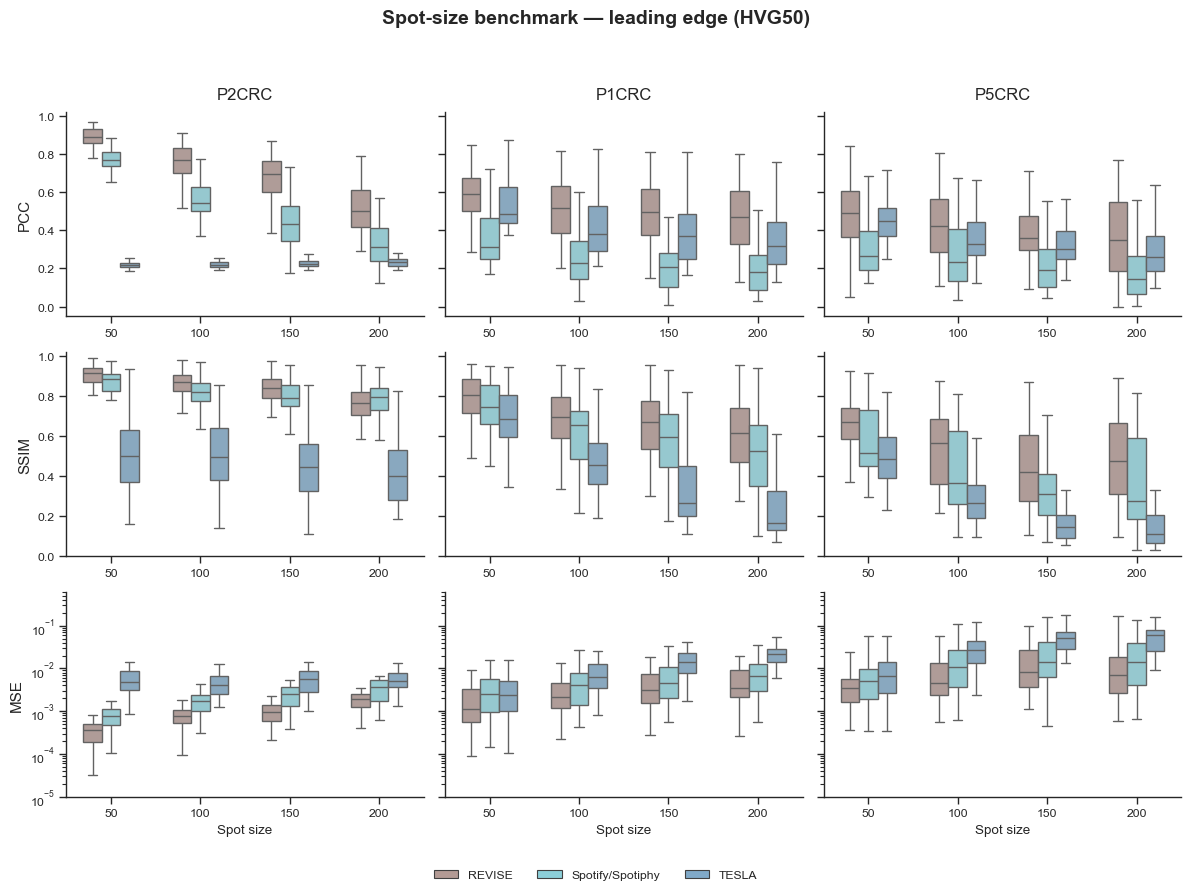

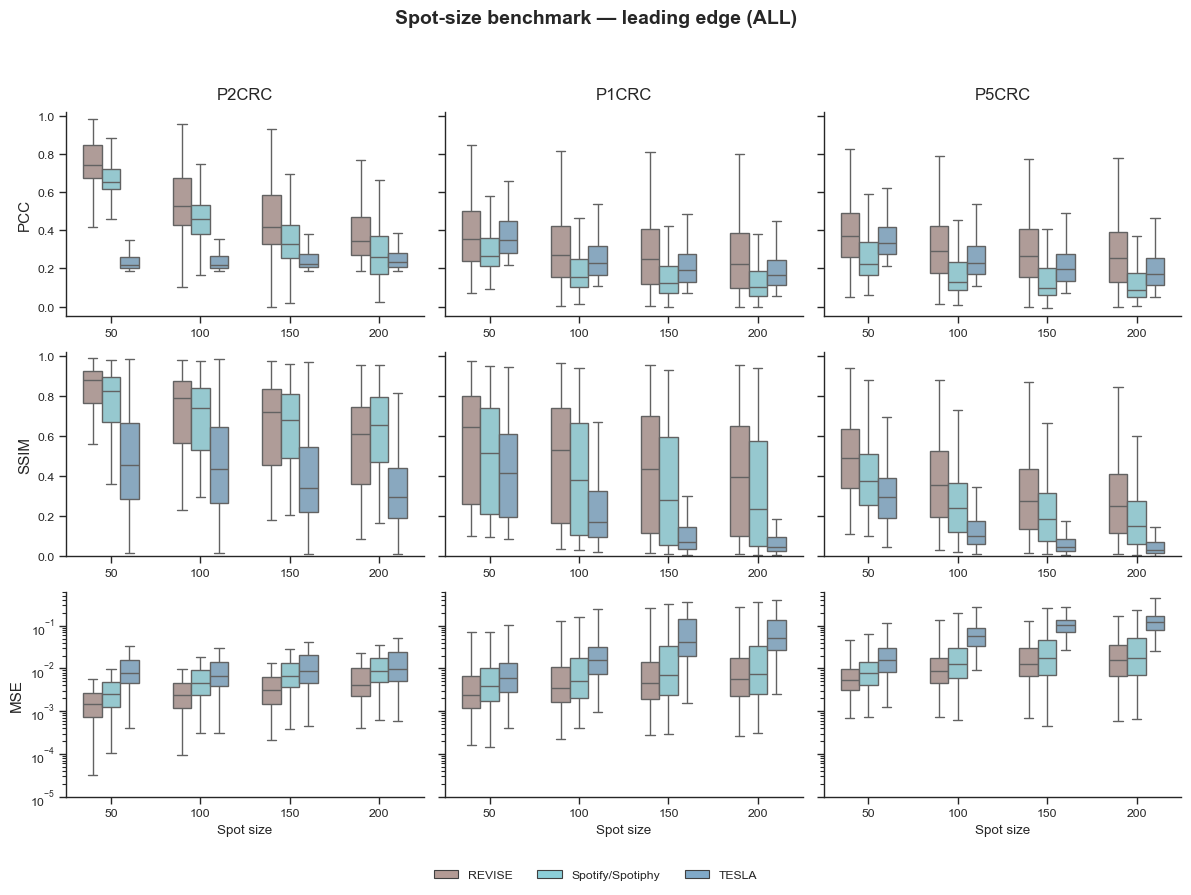

In [7]:
# [RUN] Generate the HVG50 and all-gene figures

for gene_set in ("HVG50", "ALL"):
    plot_leading_edge(gene_set)